In [1]:
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from collections import defaultdict

DATA_PATH = "D:/soccernet-data"

competitions = os.listdir(DATA_PATH)
print("Competitions found:")
for c in competitions:
    print(f"  - {c}")
print(f"\nTotal competitions: {len(competitions)}")

Competitions found:
  - england_epl
  - europe_uefa-champions-league
  - france_ligue-1
  - germany_bundesliga
  - italy_serie-a
  - spain_laliga

Total competitions: 6


In [ ]:
all_games = []

for competition in competitions:
    competition_path = os.path.join(DATA_PATH, competition)
    for season in os.listdir(competition_path):
        season_path = os.path.join(competition_path, season)
        for game in os.listdir(season_path):
            game_path = os.path.join(season_path, game)
            all_games.append(game_path)

print(f"Total games found: {len(all_games)}")
print(f"\nFirst 5 game paths:")
for g in all_games[:5]:
    print(f"  {g}")

Total games found: 500

First 5 game paths:
  D:/soccernet-data\england_epl\2014-2015\2015-02-21 - 18-00 Chelsea 1 - 1 Burnley
  D:/soccernet-data\england_epl\2014-2015\2015-02-21 - 18-00 Crystal Palace 1 - 2 Arsenal
  D:/soccernet-data\england_epl\2014-2015\2015-02-21 - 18-00 Swansea 2 - 1 Manchester United
  D:/soccernet-data\england_epl\2014-2015\2015-02-22 - 19-15 Southampton 0 - 2 Liverpool
  D:/soccernet-data\england_epl\2014-2015\2015-04-11 - 19-30 Burnley 0 - 1 Arsenal


: 

In [ ]:
action_counts = defaultdict(int)
total_annotations = 0
games_with_labels = 0
games_without_labels = 0

for game_path in all_games:
    label_path = os.path.join(game_path, "Labels-v2.json")
    
    if not os.path.exists(label_path):
        games_without_labels += 1
        continue
    
    games_with_labels += 1
    with open(label_path, "r") as f:
        data = json.load(f)
    
    for annotation in data["annotations"]:
        action_counts[annotation["label"]] += 1
        total_annotations += 1

print(f"Games with labels: {games_with_labels}")
print(f"Games without labels: {games_without_labels}")
print(f"Total annotations: {total_annotations}")
print(f"\nAction counts (sorted by frequency):")
for action, count in sorted(action_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {action}: {count}")

Games with labels: 500
Games without labels: 0
Total annotations: 110458

Action counts (sorted by frequency):
  Ball out of play: 31810
  Throw-in: 18918
  Foul: 11674
  Indirect free-kick: 10521
  Clearance: 7896
  Shots on target: 5820
  Shots off target: 5256
  Corner: 4836
  Substitution: 2839
  Kick-off: 2566
  Direct free-kick: 2200
  Offside: 2098
  Yellow card: 2047
  Goal: 1703
  Penalty: 173
  Red card: 55
  Yellow->red card: 46


: 

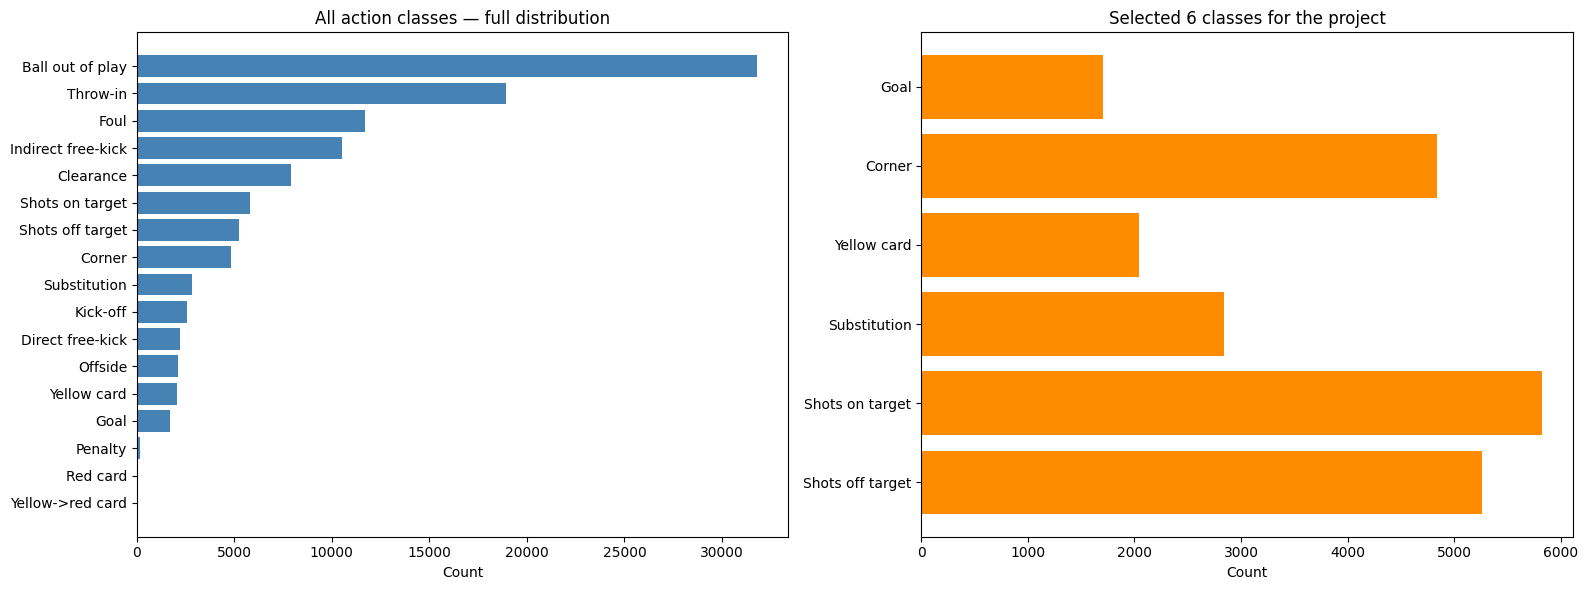

Figure saved to results/figures/


: 

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

actions = list(action_counts.keys())
counts = list(action_counts.values())
sorted_pairs = sorted(zip(counts, actions), reverse=True)
counts_sorted, actions_sorted = zip(*sorted_pairs)

ax1.barh(actions_sorted, counts_sorted, color="steelblue")
ax1.set_xlabel("Count")
ax1.set_title("All action classes — full distribution")
ax1.invert_yaxis()

selected_classes = ["Goal", "Corner", "Yellow card", "Substitution", 
                    "Shots on target", "Shots off target"]
selected_counts = [action_counts[c] for c in selected_classes]

ax2.barh(selected_classes, selected_counts, color="darkorange")
ax2.set_xlabel("Count")
ax2.set_title("Selected 6 classes for the project")
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig("../results/figures/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to results/figures/")

In [ ]:
sample_game = all_games[0]
half1_path = os.path.join(sample_game, "1_ResNET_TF2_PCA512.npy")
half2_path = os.path.join(sample_game, "2_ResNET_TF2_PCA512.npy")

half1 = np.load(half1_path)
half2 = np.load(half2_path)

print(f"Game: {os.path.basename(sample_game)}")
print(f"\nHalf 1 shape: {half1.shape}")
print(f"Half 2 shape: {half2.shape}")
print(f"\nWhat this means:")
print(f"  Frames in half 1: {half1.shape[0]} ({half1.shape[0]/2/60:.1f} minutes at 2fps)")
print(f"  Frames in half 2: {half2.shape[0]} ({half2.shape[0]/2/60:.1f} minutes at 2fps)")
print(f"  Feature dimensions per frame: {half1.shape[1]}")
print(f"\nFeature statistics for half 1:")
print(f"  Min value: {half1.min():.4f}")
print(f"  Max value: {half1.max():.4f}")
print(f"  Mean value: {half1.mean():.4f}")
print(f"  Std value: {half1.std():.4f}")

Game: 2015-02-21 - 18-00 Chelsea 1 - 1 Burnley

Half 1 shape: (5400, 512)
Half 2 shape: (5400, 512)

What this means:
  Frames in half 1: 5400 (45.0 minutes at 2fps)
  Frames in half 2: 5400 (45.0 minutes at 2fps)
  Feature dimensions per frame: 512

Feature statistics for half 1:
  Min value: -32.9692
  Max value: 29.8691
  Mean value: 0.0117
  Std value: 1.2773


: 

In [ ]:
label_path = os.path.join(sample_game, "Labels-v2.json")
with open(label_path, "r") as f:
    data = json.load(f)

print(f"Game: {os.path.basename(sample_game)}")
print(f"Total annotations in this game: {len(data['annotations'])}")
print(f"\nAll annotations:")
for ann in data["annotations"]:
    
    game_time = ann["gameTime"]
    half = int(game_time.split(" - ")[0])
    time_str = game_time.split(" - ")[1]
    minutes, seconds = map(int, time_str.split(":"))
    total_seconds = minutes * 60 + seconds
    frame_index = int(total_seconds * 2)
    
    print(f"  [{ann['label']}] Half {half} | {time_str} | "
          f"position={ann['position']}ms | frame_index={frame_index}")

Game: 2015-02-21 - 18-00 Chelsea 1 - 1 Burnley
Total annotations in this game: 190

All annotations:
  [Kick-off] Half 1 | 00:00 | position=0ms | frame_index=0
  [Ball out of play] Half 1 | 02:13 | position=133295ms | frame_index=266
  [Throw-in] Half 1 | 02:29 | position=149168ms | frame_index=298
  [Ball out of play] Half 1 | 02:36 | position=156098ms | frame_index=312
  [Corner] Half 1 | 03:02 | position=182775ms | frame_index=364
  [Ball out of play] Half 1 | 04:06 | position=246619ms | frame_index=492
  [Throw-in] Half 1 | 04:18 | position=258040ms | frame_index=516
  [Shots on target] Half 1 | 04:30 | position=270441ms | frame_index=540
  [Ball out of play] Half 1 | 04:31 | position=271751ms | frame_index=542
  [Corner] Half 1 | 04:52 | position=292492ms | frame_index=584
  [Offside] Half 1 | 05:19 | position=319710ms | frame_index=638
  [Shots on target] Half 1 | 05:47 | position=347458ms | frame_index=694
  [Offside] Half 1 | 06:35 | position=395728ms | frame_index=790
  [Ball 

: 

In [ ]:
SELECTED_CLASSES = ["Goal", "Corner", "Yellow card", 
                    "Substitution", "Shots on target", "Shots off target"]

annotations_per_game = []
selected_counts_per_class = defaultdict(int)
games_with_zero = 0

for game_path in all_games:
    label_path = os.path.join(game_path, "Labels-v2.json")
    with open(label_path, "r") as f:
        data = json.load(f)
    
    game_annotations = [a for a in data["annotations"] 
                        if a["label"] in SELECTED_CLASSES]
    annotations_per_game.append(len(game_annotations))
    
    for ann in game_annotations:
        selected_counts_per_class[ann["label"]] += 1
    
    if len(game_annotations) == 0:
        games_with_zero += 1

print("Selected class totals across all 500 games:")
for cls in SELECTED_CLASSES:
    print(f"  {cls}: {selected_counts_per_class[cls]}")

print(f"\nTotal selected annotations: {sum(selected_counts_per_class.values())}")
print(f"Games with zero selected annotations: {games_with_zero}")
print(f"\nAnnotations per game statistics:")
print(f"  Min: {min(annotations_per_game)}")
print(f"  Max: {max(annotations_per_game)}")
print(f"  Mean: {np.mean(annotations_per_game):.1f}")
print(f"  Median: {np.median(annotations_per_game):.1f}")

Selected class totals across all 500 games:
  Goal: 1703
  Corner: 4836
  Yellow card: 2047
  Substitution: 2839
  Shots on target: 5820
  Shots off target: 5256

Total selected annotations: 22501
Games with zero selected annotations: 0

Annotations per game statistics:
  Min: 21
  Max: 72
  Mean: 45.0
  Median: 45.0


: 

In [ ]:
from SoccerNet.utils import getListGames

train_games = getListGames("train")
valid_games = getListGames("valid")
test_games = getListGames("test")

print(f"Train games: {len(train_games)}")
print(f"Valid games: {len(valid_games)}")
print(f"Test games: {len(test_games)}")
print(f"\nSample train game entry: {train_games[0]}")

Train games: 300
Valid games: 100
Test games: 100

Sample train game entry: england_epl\2014-2015\2015-02-21 - 18-00 Chelsea 1 - 1 Burnley


: 

In [ ]:
split_mapping = {}
for game in train_games:
    split_mapping[game] = "train"
for game in valid_games:
    split_mapping[game] = "valid"
for game in test_games:
    split_mapping[game] = "test"

split_stats = {
    "train": defaultdict(int),
    "valid": defaultdict(int),
    "test": defaultdict(int)
}
split_game_counts = {"train": 0, "valid": 0, "test": 0}

for game_path in all_games:
    label_path = os.path.join(game_path, "Labels-v2.json")
    with open(label_path, "r") as f:
        data = json.load(f)
    
    url_local = data.get("UrlLocal", "").replace("/", "\\").rstrip("\\")
    split = split_mapping.get(url_local, None)
    
    if split is None:
        continue
    
    split_game_counts[split] += 1
    for ann in data["annotations"]:
        if ann["label"] in SELECTED_CLASSES:
            split_stats[split][ann["label"]] += 1

for split in ["train", "valid", "test"]:
    total = sum(split_stats[split].values())
    print(f"\n{split.upper()} — {split_game_counts[split]} games, {total} annotations")
    for cls in SELECTED_CLASSES:
        print(f"  {cls}: {split_stats[split][cls]}")


TRAIN — 300 games, 13494 annotations
  Goal: 995
  Corner: 2884
  Yellow card: 1238
  Substitution: 1700
  Shots on target: 3463
  Shots off target: 3214

VALID — 100 games, 4428 annotations
  Goal: 371
  Corner: 953
  Yellow card: 378
  Substitution: 560
  Shots on target: 1182
  Shots off target: 984

TEST — 100 games, 4579 annotations
  Goal: 337
  Corner: 999
  Yellow card: 431
  Substitution: 579
  Shots on target: 1175
  Shots off target: 1058


: 

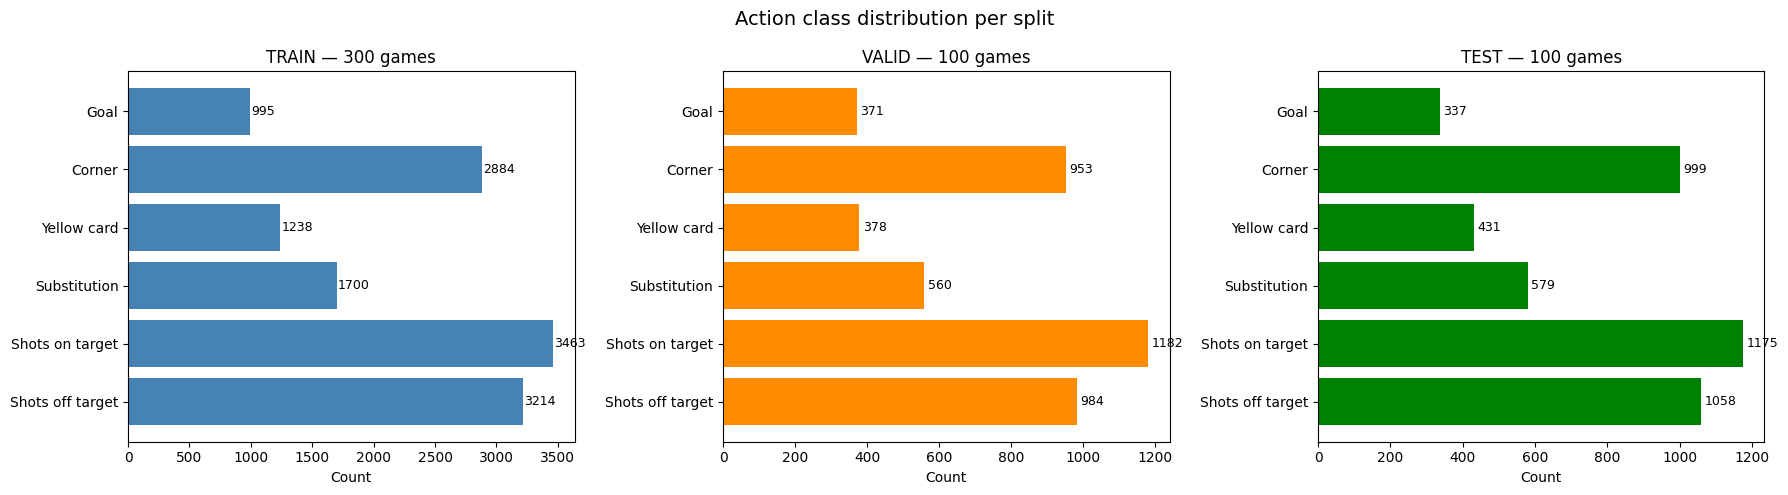

Figure saved to results/figures/


: 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {"train": "steelblue", "valid": "darkorange", "test": "green"}

for idx, split in enumerate(["train", "valid", "test"]):
    counts = [split_stats[split][cls] for cls in SELECTED_CLASSES]
    axes[idx].barh(SELECTED_CLASSES, counts, color=colors[split])
    axes[idx].set_title(f"{split.upper()} — {split_game_counts[split]} games")
    axes[idx].set_xlabel("Count")
    axes[idx].invert_yaxis()
    for i, count in enumerate(counts):
        axes[idx].text(count + 10, i, str(count), va="center", fontsize=9)

plt.suptitle("Action class distribution per split", fontsize=14)
plt.tight_layout()
plt.savefig("../results/figures/split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to results/figures/")

In [ ]:
import sys
sys.path.append("../src")

from dataset import SoccerNetDataset
from torch.utils.data import DataLoader

DATA_PATH = "D:/soccernet-data"

train_dataset = SoccerNetDataset(
    data_path=DATA_PATH,
    split="train",
    window_size=60,
    overlap=0.5
)

Class to index mapping:
  Goal: 0
  Corner: 1
  Yellow card: 2
  Substitution: 3
  Shots on target: 4
  Shots off target: 5
  Background: 6
Loading train split — 300 games...
  Total samples: 100669


: 

In [ ]:
from collections import Counter

from dataset import IDX_TO_CLASS, BACKGROUND_IDX

labels = [label for _, label in train_dataset.samples]
label_counts = Counter(labels)

print("Sample counts per class:")
for idx, cls in IDX_TO_CLASS.items():
    print(f"  {cls}: {label_counts[idx]}")
print(f"  Background: {label_counts[BACKGROUND_IDX]}")

print(f"\nTotal action samples: {sum(label_counts[i] for i in range(len(SELECTED_CLASSES)))}")
print(f"Total background samples: {label_counts[BACKGROUND_IDX]}")

window, label = train_dataset[0]
print(f"\nSample window shape: {window.shape}")
print(f"Sample label: {label.item()} ({IDX_TO_CLASS.get(label.item(), 'Background')})")

Sample counts per class:
  Goal: 965
  Corner: 2883
  Yellow card: 1233
  Substitution: 1672
  Shots on target: 3127
  Shots off target: 3211
  Background: 87578

Total action samples: 13091
Total background samples: 87578

Sample window shape: torch.Size([60, 512])
Sample label: 1 (Corner)


: 

In [ ]:
valid_dataset = SoccerNetDataset(
    data_path=DATA_PATH,
    split="valid",
    window_size=60,
    overlap=0.5
)

test_dataset = SoccerNetDataset(
    data_path=DATA_PATH,
    split="test",
    window_size=60,
    overlap=0.5
)

print(f"\nDataset summary:")
print(f"  Train samples: {len(train_dataset)}")
print(f"  Valid samples: {len(valid_dataset)}")
print(f"  Test samples:  {len(test_dataset)}")

Loading valid split — 100 games...
  Total samples: 33618
Loading test split — 100 games...
  Total samples: 33532

Dataset summary:
  Train samples: 100669
  Valid samples: 33618
  Test samples:  33532


: 

In [ ]:
import sys
sys.path.append("../src")

from dataset import get_dataloader, IDX_TO_CLASS, SELECTED_CLASSES
from collections import Counter
import torch

train_loader = get_dataloader(train_dataset, batch_size=32, use_weighted_sampler=True)
valid_loader = get_dataloader(valid_dataset, batch_size=32, shuffle=False)
test_loader = get_dataloader(test_dataset, batch_size=32, shuffle=False)

batch_windows, batch_labels = next(iter(train_loader))
print(f"Batch windows shape: {batch_windows.shape}")
print(f"Batch labels shape: {batch_labels.shape}")
print(f"Labels in this batch: {batch_labels.tolist()}")
print(f"\nClass distribution in this batch:")
batch_counts = Counter(batch_labels.tolist())
for idx in range(len(SELECTED_CLASSES) + 1):
    cls_name = IDX_TO_CLASS.get(idx, "Background")
    print(f"  {cls_name}: {batch_counts.get(idx, 0)}")

Batch windows shape: torch.Size([32, 60, 512])
Batch labels shape: torch.Size([32])
Labels in this batch: [3, 2, 6, 3, 2, 2, 3, 3, 2, 4, 3, 1, 6, 3, 2, 6, 0, 3, 1, 4, 3, 0, 1, 1, 6, 1, 0, 3, 2, 4, 2, 5]

Class distribution in this batch:
  Goal: 3
  Corner: 5
  Yellow card: 7
  Substitution: 9
  Shots on target: 3
  Shots off target: 1
  Background: 4


: 

In [ ]:
import sys
sys.path.append("../src")

from model import SoccerNetTransformer
import torch

model = SoccerNetTransformer(
    input_dim=512,
    d_model=256,
    num_heads=4,
    num_layers=3,
    dim_feedforward=512,
    dropout=0.1,
    num_classes=7
)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

batch_windows, batch_labels = next(iter(train_loader))
output = model(batch_windows)

print(f"\nInput shape: {batch_windows.shape}")
print(f"Output shape: {output.shape}")
print(f"Output (first sample): {output[0].detach().numpy().round(4)}")

SoccerNetTransformer(
  (input_projection): Linear(in_features=512, out_features=256, bias=True)
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=256, out_features=7, bias=True)
)

Total parameters: 1,71

NameError: name 'train_loader' is not defined

: 

: 